# DZNE vs PEC — Cross-validation via Mitiq

Mirror notebook of `my_dzne.ipynb`, using the Mitiq API rather than a from-scratch implementation.
Objective: cross-validation on the same 20 seeds and access to PEC.

**Structure:**
1. Setup (imports, noise model, executor)
2. Benchmark (Pauli-randomized mirror circuit, P(success), N seeds)
3. DZNE with Mitiq — single-circuit demos (folding, factories, AdaExp)
4. PEC with Mitiq — single-circuit demos (representations, LP construction)
5. Unified benchmark — Depolarizing (20-seed stats: ZNE + PEC, equal shot budget, cached)
6. Extension to other noise models (amplitude/phase damping, thermal)

**Method:** §3–§4 illustrate *how* each technique works on one circuit (seed=0); all multi-seed
statistics come from a single cached pipeline `cached_benchmark(spec)` (§5 depolarizing, §6 others),
so every method is compared at equal cost under one methodology.

**Key point:** Mitiq 1.0.0 is a transparent frontend — accepts and returns Qiskit circuits directly.
The circuit is pre-transpiled to basis gates **before** folding to ensure linear noise scaling.

## 1. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import transpile, QuantumCircuit
from qiskit_aer import AerSimulator
from mitiq import zne, pec
from mitiq.zne.scaling import fold_global, fold_all, fold_gates_at_random
from mitiq.zne.inference import RichardsonFactory, PolyFactory, ExpFactory, AdaExpFactory

# All project machinery lives in the qem/ package (definitions only -- no simulations).
# This single import removes the cell-ordering dependencies the notebook used to have.
# Make qem importable regardless of the kernel working directory:
import sys
from pathlib import Path
for _cand in (Path.cwd(), Path.cwd() / "notebooks", *Path.cwd().parents):
    if (_cand / "qem" / "__init__.py").exists():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        break
from qem import *
# _assert_all_ops_represented is private (not re-exported by import *);
# the section 4 PEC demo cells use it directly:
from qem.benchmark import _assert_all_ops_represented

print("qem loaded. Specs:", [s.name for s in (SPEC_DEPOL, SPEC_AD, SPEC_PD, SPEC_TH, SPEC_TH_REAL, SPEC_MIXED_UNITARY)])

qem loaded. Specs: ['Depolarizing', 'AmplitudeDamping', 'PhaseDamping', 'ThermalRelaxation', 'ThermalRealistic', 'MixedUnitary']


In [2]:
# Global parameters now live in qem.config (P1, P2, SHOTS, SEEDS, BASIS_GATES, ...).
# Demo backends used by the illustrations below:
noisy_backend = AerSimulator(noise_model=SPEC_DEPOL.build_noise_model())
ideal_backend = AerSimulator()
print(f"P1={P1}  P2={P2}  SHOTS={SHOTS}  N_SEEDS={N_SEEDS}  basis={BASIS_GATES}")


P1=0.01  P2=0.05  SHOTS=10000  N_SEEDS=20  basis=['h', 'rz', 'sx', 'x', 'cx', 'id', 'sxdg']


In [3]:
# Smoke test on a Bell circuit (target |00> -> ~0.5). make_executor comes from qem.
bell = QuantumCircuit(2); bell.h(0); bell.cx(0, 1)
print(f"Bell P(00) ideal: {make_executor(ideal_backend, '00')(bell):.4f}  (expected ~ 0.50)")
print(f"Bell P(00) noisy: {make_executor(noisy_backend, '00')(bell):.4f}  (expected < 0.50)")


Bell P(00) ideal: 0.5012  (expected ~ 0.50)
Bell P(00) noisy: 0.4957  (expected < 0.50)


## 2. Benchmark

Mitiq Pauli-randomized **mirror circuit** (Proctor et al., PRL 2022): random Clifford layers and their inverse, with random Pauli layers inserted so the ideal outcome is a known bitstring (P(success)=1) while the artificial echo-cancellation of a naive U.U^-1 is suppressed.

**Pre-transpilation:** transpile to `BASIS_GATES` with `optimization_level=0` (no algebraic simplification)  
**before** passing the circuit to Mitiq. Without this, `fold_global` generates gates outside the noise model and noise  
does not scale linearly with λ.

Mirror seed=0 -- target bitstring: 01
Gates (seed=0): {'rz': 18, 'x': 16, 'cx': 10, 'id': 8, 'h': 4, 'sxdg': 3, 'sx': 3}
Depth    : 43


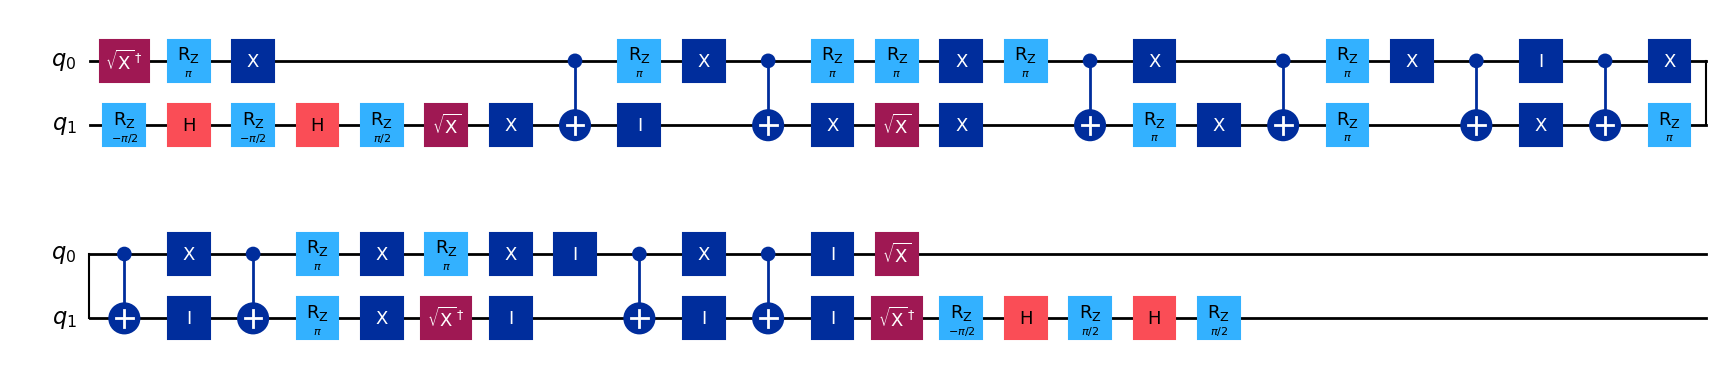

In [4]:
# Mirror-circuit helpers come from qem (make_benchmark_circuit / target_key / mitiq_executor).
circ0 = make_benchmark_circuit(0)
print(f"Mirror seed=0 -- target bitstring: {target_key(0)}")
print("Gates (seed=0):", dict(circ0.count_ops()))
print(f"Depth    : {circ0.depth()}")
circ0.draw("mpl")


In [5]:
# Ideal validation: each seed's mirror returns its OWN target bitstring w.p. ~1.0.
# This is the key sanity check after the swap -- it catches any bitstring/endianness bug.
ideal_spot = [success_prob(ideal_backend, s) for s in range(5)]
print("Ideal (seeds 0..4):", [f"{v:.4f}" for v in ideal_spot])
print("Targets           :", [target_key(s) for s in range(5)])
assert all(v > 0.99 for v in ideal_spot), "Mirror target/endianness mismatch!"

Ideal (seeds 0..4): ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
Targets           : ['01', '01', '00', '00', '00']


Computing noisy baseline...
P(success) noisy -- mean=0.5179  std=0.0282
R_u              -- mean=0.5179  std=0.0282


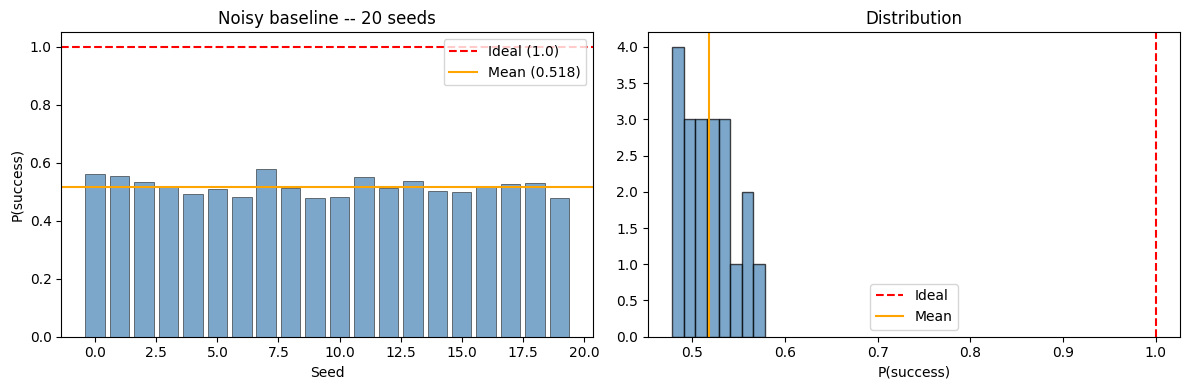

In [6]:
# Noisy baseline over 20 seeds (each vs its own target bitstring)
print("Computing noisy baseline...")
noisy_vals = np.array([success_prob(noisy_backend, s) for s in SEEDS])
R_u = noisy_vals / IDEAL

print(f"P(success) noisy -- mean={noisy_vals.mean():.4f}  std={noisy_vals.std():.4f}")
print(f"R_u              -- mean={R_u.mean():.4f}  std={R_u.std():.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(SEEDS, noisy_vals, color="steelblue", alpha=0.7, edgecolor="black", linewidth=0.5)
ax1.axhline(IDEAL, color="red", ls="--", lw=1.5, label=f"Ideal ({IDEAL:.1f})")
ax1.axhline(noisy_vals.mean(), color="orange", ls="-", lw=1.5,
            label=f"Mean ({noisy_vals.mean():.3f})")
ax1.set_xlabel("Seed"); ax1.set_ylabel("P(success)")
ax1.set_title("Noisy baseline -- 20 seeds"); ax1.legend()
ax2.hist(noisy_vals, bins=8, color="steelblue", alpha=0.7, edgecolor="black")
ax2.axvline(IDEAL, color="red", ls="--", lw=1.5, label="Ideal")
ax2.axvline(noisy_vals.mean(), color="orange", ls="-", lw=1.5, label="Mean")
ax2.set_xlabel("P(success)"); ax2.set_title("Distribution")
ax2.legend()
plt.tight_layout(); plt.show()

## 3. DZNE with Mitiq

**Mitiq ↔ DZNE paper mapping:**

| Mitiq | Model | Adaptive | Corresponds to |
|---|---|---|---|
| `RichardsonFactory` | Lagrange → λ=0 | No | TBG original |
| `PolyFactory(order=2)` | Degree-2 poly | No | Non-adaptive DZNE poly |
| `ExpFactory(asymptote=a)` | `a + b·exp(-cλ)` | No | Non-adaptive DZNE exp |
| `AdaExpFactory(steps, scale_factor)` | Exp | **Yes** | **Algorithm 3** |
| — | Adaptive Poly-2 | Yes | **Algorithm 2** (custom only) |

⚠️ **Algorithm 2** (adaptive) has no equivalent in Mitiq — only the custom notebook implements it.

### 3.1 Folding methods

Mitiq 1.0.0 provides:
- `fold_global` : $U \to U(U^\dagger U)^n$ — folds the entire circuit, preserves layer order
- `fold_all` : folds all gates in place — only works at odd integers (1×, 3×, 5×…)
- `fold_gates_at_random` : selects random gates for partial folding

For non-integer λ (e.g. 1.5), `fold_global` performs **partial folding** — not rounding to the nearest odd integer.

In [7]:
circ0  = make_benchmark_circuit(0)
n_orig = sum(circ0.count_ops().values())
print(f"Original circuit: {n_orig} gates — {dict(circ0.count_ops())}\n")

methods = [
    ('fold_global',          lambda c, sf: fold_global(c, sf)),
    ('fold_all',             lambda c, sf: fold_all(c, sf)),
    ('fold_gates_at_random', lambda c, sf: fold_gates_at_random(c, sf, seed=42)),
]

print(f"{'Method':<25} {'λ=1.0':>7} {'λ=1.5':>7} {'λ=2.0':>7} {'λ=3.0':>7}")
print('-' * 58)
for name, fn in methods:
    row = []
    for sf in [1.0, 1.5, 2.0, 3.0]:
        folded = fn(circ0, sf)
        row.append(f"{sum(folded.count_ops().values()):6d}")
    print(f"{name:<25}  {'  '.join(row)}")

Original circuit: 62 gates — {'rz': 18, 'x': 16, 'cx': 10, 'id': 8, 'h': 4, 'sxdg': 3, 'sx': 3}

Method                      λ=1.0   λ=1.5   λ=2.0   λ=3.0
----------------------------------------------------------
fold_global                    62      94     124     186
fold_all                       62      62      62     186
fold_gates_at_random           62      92     124     186


In [8]:
# fold_global — exact scaling vs λ
print(f"{'\u03bb':>5} {'n_gates':>10} {'observed ratio':>15} {'expected \u03bb':>12}")
print('-' * 47)
for sf in [1.0, 1.5, 2.0, 2.5, 3.0]:
    folded = fold_global(circ0, scale_factor=sf)
    n_fold = sum(folded.count_ops().values())
    ratio  = n_fold / n_orig
    print(f"{sf:>5.1f} {n_fold:>10d} {ratio:>15.3f} {sf:>12.3f}")
print("\n→ fold_global targets ratio = exact λ (partial folding, not odd-integer rounding).")

    λ    n_gates  observed ratio   expected λ
-----------------------------------------------
  1.0         62           1.000        1.000
  1.5         94           1.516        1.500
  2.0        124           2.000        2.000
  2.5        154           2.484        2.500
  3.0        186           3.000        3.000

→ fold_global targets ratio = exact λ (partial folding, not odd-integer rounding).


### 3.2 Non-adaptive factories

`fold_global` is used as the scaling method (consistent with the custom notebook), λ ∈ {1.0, 1.5, 2.0}.

Note on `ExpFactory`: the theoretical asymptote for 2-qubit depolarizing noise is $1/4 = 0.25$
(maximally mixed state as λ → ∞).

In [9]:
circ0   = make_benchmark_circuit(0)
ex0     = mitiq_executor(noisy_backend, 0)
noisy_0 = ex0(circ0)

factories_nonadapt = {
    "Richardson": RichardsonFactory(scale_factors=SCALE_FACTORS),
    "Poly2"     : PolyFactory(scale_factors=SCALE_FACTORS, order=2),
    "Exp"       : ExpFactory(scale_factors=SCALE_FACTORS, asymptote=0.25),
}

results_seed0 = {"Noisy": noisy_0}

print(f"Seed=0 -- noisy baseline: {noisy_0:.4f}  (ideal={IDEAL:.1f})")
print(f"{'Factory':<12}  {'val':>8}  {'|err|':>8}")
print("-" * 35)
for name, factory in factories_nonadapt.items():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        val = zne.execute_with_zne(circ0, ex0, factory=factory, scale_noise=fold_global)
    results_seed0[name] = val
    print(f"{name:<12}  {val:>8.4f}  {abs(val-IDEAL):>8.4f}")

Seed=0 -- noisy baseline: 0.5696  (ideal=1.0)
Factory            val     |err|
-----------------------------------
Richardson      0.7085    0.2915
Poly2           0.8365    0.1635
Exp             0.9890    0.0110


### 3.3 Adaptive factory — AdaExpFactory (≈ Algorithm 3)

`AdaExpFactory` chooses scale factors **adaptively**: after each measurement,
it selects the next λ to minimize uncertainty on the exponential estimator.  
This is the Mitiq equivalent of Algorithm 3 from the DZNE paper.

Parameters: `steps=4`, `scale_factor=2.0` (initial growth factor), `asymptote=0.25`.

AdaExp ZNE (seed=0): 1.0115  (ideal=1.0)
Chosen scale factors : ['1.00', '2.00', '2.50', '2.55']
Measured values      : ['0.5658', '0.3849', '0.3432', '0.3205']


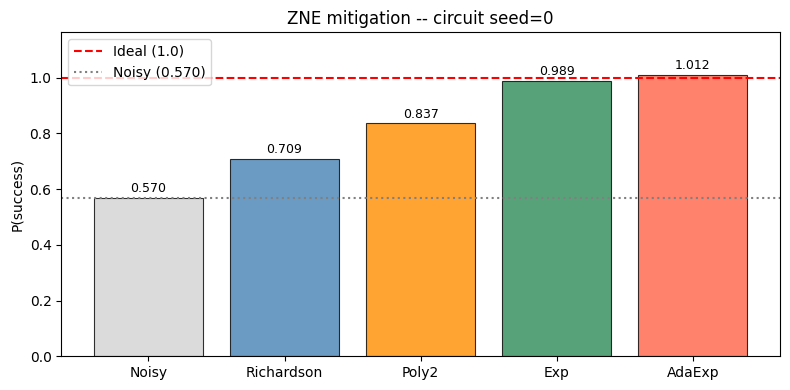

In [10]:
circ0 = make_benchmark_circuit(0)
ex0   = mitiq_executor(noisy_backend, 0)
ada_factory = AdaExpFactory(steps=4, scale_factor=2.0, asymptote=0.25)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    val_ada = zne.execute_with_zne(circ0, ex0, factory=ada_factory, scale_noise=fold_global)

print(f"AdaExp ZNE (seed=0): {val_ada:.4f}  (ideal={IDEAL:.1f})")
print(f"Chosen scale factors : {[f'{v:.2f}' for v in ada_factory.get_scale_factors()]}")
print(f"Measured values      : {[f'{v:.4f}' for v in ada_factory.get_expectation_values()]}")
results_seed0["AdaExp"] = val_ada

# Comparative barplot seed=0
labels = list(results_seed0.keys())
vals   = [results_seed0[k] for k in labels]
colors = ["lightgray", "steelblue", "darkorange", "seagreen", "tomato"]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, vals, color=colors, alpha=0.8, edgecolor="black", linewidth=0.8)
ax.axhline(IDEAL, color="red", ls="--", lw=1.5, label=f"Ideal ({IDEAL})")
ax.axhline(noisy_0, color="gray", ls=":", lw=1.5, label=f"Noisy ({noisy_0:.3f})")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("P(success)"); ax.set_ylim(0, max(max(vals) * 1.15, 1.1))
ax.set_title("ZNE mitigation -- circuit seed=0"); ax.legend()
plt.tight_layout(); plt.show()

### Section 3 summary

§3 is **illustrative** (single circuit, seed=0): it shows how folding, the non-adaptive factories
and the adaptive `AdaExpFactory` behave. The **20-seed statistics** (bias / variance / MSE) for
these DZNE methods are produced — alongside PEC and at equal shot budget — by the unified pipeline
in **§5** (depolarizing) and **§6** (other noise models).

**To compare with the custom notebook** (numbers in §5):
- `AdaExp` (Mitiq) vs `Algorithm 3` (custom) — expected close up to MC variance
- Non-adaptive `Exp` expected dominant (exact ansatz = depolarizing noise)
- `Poly2` penalized by the wrong ansatz (polynomial over exponential noise)
- Algorithm 2 (custom only) — original contribution, not reproducible via Mitiq

**Next step:** Section 4 — PEC with `mitiq.pec`.

## 4. PEC with Mitiq

Probabilistic Error Cancellation via `mitiq.pec`. This section is a **single-circuit demo**
(seed=0): how to build the three pieces and validate the representations. The **20-seed PEC
statistics** live in §5/§6 via `cached_benchmark`.

Three pieces: **(1) executor** (reused from §1), **(2) OperationRepresentations**, **(3) execute_with_pec**.

Key convention trap: Aer uses the **replacement** parameterisation `λ`, Mitiq uses the **Pauli** parameterisation `p`.
Conversion: `p_1q = (3/4)·λ_1q`,  `p_2q = (15/16)·λ_2q`.

In [11]:
# Aer (replacement) -> Mitiq (Pauli) convention; constants imported from qem.config.
print(f"P1 (Aer)  = {P1}   ->  P_MITIQ_1Q = {P_MITIQ_1Q}")
print(f"P2 (Aer)  = {P2}   ->  P_MITIQ_2Q = {P_MITIQ_2Q}")
print(f"gamma_theory (1q)             = {gamma_1q_theory:.6f}")
print(f"gamma_theory (2q LOCAL  DxD)  = {gamma_2q_local_theory:.6f}")
print(f"gamma_theory (2q GLOBAL D2q)  = {gamma_2q_global_theory:.6f}  (correct for Aer)")


P1 (Aer)  = 0.01   ->  P_MITIQ_1Q = 0.0075
P2 (Aer)  = 0.05   ->  P_MITIQ_2Q = 0.046875
gamma_theory (1q)             = 1.015152
gamma_theory (2q LOCAL  DxD)  = 1.210000
gamma_theory (2q GLOBAL D2q)  = 1.098684  (correct for Aer)


### 4.2 Representations

- **1-qubit gates** (h, rz, sx, x, sxdg, id): local depolarising at `P_MITIQ_1Q`  
  via `represent_operations_in_circuit_with_local_depolarizing_noise` (local ≡ global on 1 qubit).
- **CX gate**: **GLOBAL** 2q depolarising at `P_MITIQ_2Q` via  
  `represent_operation_with_global_depolarizing_noise` on a Qiskit cx-only circuit.

> ⚠️ **Fix vs initial version**: the original code used the LOCAL helper for the CX, which models  
> noise as `D ⊗ D` (independent 1q channels) instead of Aer's true 2q-global channel. That introduced  
> a model mismatch (PEC bias ≈ −0.10, γ_local/γ_global ≈ 1.10× overhead penalty).

> ⚠️ Using `cirq.CNOT` directly (Cirq native) **does not match** the Qiskit cx after Mitiq's internal  
> conversion — always build CX reps from a Qiskit circuit.

In [12]:
def build_representations(circuit):
    """Representations coherent with the AerSimulator noise model.

    Fix vs initial implementation:
      - 1-qubit gates : local depolarizing helper (== global for 1q).
      - CX (2-qubit)  : GLOBAL 2q depolarizing helper. The previous code used
        the LOCAL helper, which assumes a tensor product D⊗D of 1q channels and
        thus mis-models Aer's true 2q-global `depolarizing_error(P2, 2)`. The
        local representation has 16 terms with norm γ_local ≈ 1.21; the global
        representation also has 16 terms but with norm γ_global ≈ 1.10 — both
        smaller bias and smaller PEC overhead.
    """
    # 1-qubit reps (local == global for 1q)
    all_reps = pec.represent_operations_in_circuit_with_local_depolarizing_noise(
        circuit, noise_level=P_MITIQ_1Q
    )
    reps_1q = [r for r in all_reps if len(r.ideal.all_qubits()) == 1]

    # CX reps via GLOBAL 2q depolarizing helper (analytical, matches Aer).
    # BUGFIX: random Clifford circuits contain CX in BOTH orientations. Building a
    # rep only for cx(0,1) left every cx(1,0) UN-mitigated (Mitiq emits a silenced
    # "No representation found" warning) -> large negative PEC bias (~-0.28).
    cx_reps = []
    for ctrl, tgt in [(0, 1), (1, 0)]:
        qc_cx = QuantumCircuit(2)
        qc_cx.cx(ctrl, tgt)
        cx_reps.append(pec.represent_operation_with_global_depolarizing_noise(
            qc_cx, noise_level=P_MITIQ_2Q
        ))
    return reps_1q + cx_reps


# Display on seed=0
circ0 = make_benchmark_circuit(0)
reps0 = build_representations(circ0)
print(f"Representations for seed=0: {len(reps0)} total")
print(f"{'Gate nq':<10}  {'norm (gamma)':>12}  {'match theory?':>15}")
print('-' * 42)
for r in reps0:
    nq = len(r.ideal.all_qubits())
    theory = gamma_1q_theory if nq == 1 else gamma_2q_global_theory
    match = abs(r.norm - theory) < 1e-4
    print(f"{nq:<10}  {r.norm:>12.6f}  {str(match):>15}")
print(f"gamma_theory 1q       : {gamma_1q_theory:.6f}")
print(f"gamma_theory 2q global: {gamma_2q_global_theory:.6f}  (matches Aer)")

Representations for seed=0: 15 total
Gate nq     norm (gamma)    match theory?
------------------------------------------
1               1.015152             True
1               1.015152             True
1               1.015152             True
1               1.015152             True
1               1.015152             True
1               1.015152             True
1               1.015152             True
1               1.015152             True
1               1.015152             True
1               1.015152             True
1               1.015152             True
1               1.015152             True
1               1.015152             True
2               1.098684             True
2               1.098684             True
gamma_theory 1q       : 1.015152
gamma_theory 2q global: 1.098684  (matches Aer)


### 4.3 Single-circuit demo (seed=0)

PEC executor uses `SHOTS_PEC = 10` shots per sample with `N_SAMPLES_PEC = 3000` samples.  
**Why few shots / many samples:** at a fixed total budget `B = N × shots`, the shot-noise term of
the PEC variance is set by `B` alone, while the *dominant* term — the quasi-probability sign variance
`∝ γ²/N` — only shrinks by taking more samples `N`. So `3000 × 10` beats `300 × 100` at equal cost.  
Total: `3000 × 10 = 30 k` shots/circuit, matching the ZNE budget (`3 × 10 000`) — an equal-cost demo.

In [13]:
SHOTS_PEC     = 100     # few shots / many samples: minimises PEC variance at fixed budget
N_SAMPLES_PEC = 300   

circ0        = make_benchmark_circuit(0)
executor_pec = mitiq_executor(noisy_backend, 0, SHOTS_PEC)
reps0        = build_representations(circ0)
noisy_0      = mitiq_executor(noisy_backend, 0)(circ0)

# PEC warnings surfaced (no blanket ignore); guardrail catches un-represented gates.
_assert_all_ops_represented(circ0, reps0)
pec_val, pec_data = pec.execute_with_pec(
    circ0, executor_pec, representations=reps0,
    num_samples=N_SAMPLES_PEC, full_output=True,
)

print(f"Noisy  : {noisy_0:.4f}")
print(f"PEC    : {float(pec_val):.4f}  +/-  {pec_data['pec_error']:.4f}")
print(f"Ideal  : {IDEAL:.4f}")
print(f"|error| noisy : {abs(noisy_0 - IDEAL):.4f}")
print(f"|error| PEC   : {abs(float(pec_val) - IDEAL):.4f}")

Noisy  : 0.5653
PEC    : 0.8250  +/-  0.1297
Ideal  : 1.0000
|error| noisy : 0.4347
|error| PEC   : 0.1750


### 4.4 LP-based QPR construction — validation on 1q depolarizing

For noise channels without an analytical helper (amplitude damping on 2q, phase damping, thermal
relaxation, learned noise...), Mitiq exposes `find_optimal_representation(ideal_op, noisy_basis)`
which **solves a linear program** to minimise the 1-norm γ of the quasi-probability distribution
under the constraint that the noisy basis reconstructs the ideal channel.

Internally it calls `minimize_one_norm` (scipy `LinearConstraint` + `minimize`).

References : Temme/Bravyi/Gambetta 2017 (PRL 119 180509), Endo/Benjamin/Li 2018 (PRX 8 031027),
van den Berg et al. 2023 (Pauli–Lindblad sparse).

**Validation** : on the 1q depolarizing case we already have the analytical formula
γ = (1+P1/2)/(1-P1). The LP must rediscover it to floating-point precision.

In [14]:
# Validation: LP-based vs analytical QPR on 1q depolarizing channel
from mitiq.pec.representations.depolarizing import local_depolarizing_kraus

# Use the same Aer Pauli convention (P_MITIQ_1Q = (3/4)*P1)
kraus_1q_depol = local_depolarizing_kraus(noise_level=P_MITIQ_1Q, num_qubits=1)

# Ideal operation = single H gate
qc_h = QuantumCircuit(1); qc_h.h(0)

# (a) LP-based representation
rep_lp = represent_op_with_kraus_lp(qc_h, kraus_1q_depol)

# (b) Analytical representation
rep_analytic = pec.represent_operation_with_local_depolarizing_noise(qc_h, noise_level=P_MITIQ_1Q)

print(f"gamma_analytical (formula)  : {gamma_1q_theory:.6f}")
print(f"gamma_analytical (mitiq rep): {rep_analytic.norm:.6f}")
print(f"gamma_LP                    : {rep_lp.norm:.6f}")
print(f"|gamma_LP - gamma_analytic| : {abs(rep_lp.norm - rep_analytic.norm):.2e}")
print()
print(f"LP coefficients : {sorted(rep_lp.coeffs, reverse=True)}")
print(f"Analytic coeffs : {sorted(rep_analytic.coeffs, reverse=True)}")
assert abs(rep_lp.norm - rep_analytic.norm) < 1e-4, "LP and analytical gamma must match"
print("\n[OK] LP reproduces the analytical optimal representation.")

gamma_analytical (formula)  : 1.015152
gamma_analytical (mitiq rep): 1.015152
gamma_LP                    : 1.015152
|gamma_LP - gamma_analytic| : 1.46e-08

LP coefficients : [1.0075757502779743, -0.0025252500926580346, -0.0025252500926580346, -0.002525250092658241]
Analytic coeffs : [1.0075757575757576, -0.002525252525252525, -0.002525252525252525, -0.002525252525252525]

[OK] LP reproduces the analytical optimal representation.


## 5. Unified benchmark — Depolarizing

From here on, every multi-seed result comes from **one** pipeline: a `NoiseSpec` dataclass + a single
`cached_benchmark(spec)` call (a disk-cached wrapper over `run_benchmark`, surviving kernel restarts).

A `NoiseSpec` carries:
- `name`
- `build_noise_model()` → an Aer `NoiseModel`
- `build_representations(circuit)` → list of Mitiq `OperationRepresentation`
- `asymptote` for `ExpFactory`/`AdaExpFactory` (state P(|00⟩) at λ→∞)
- `pec_num_samples`

Generic building blocks (Pauli-basis LP via `find_optimal_representation`) let exotic noise models
without an analytical helper still produce a QPR.

This first run uses `SPEC_DEPOL`: a **single** seeded `cached_benchmark(SPEC_DEPOL)` call produces the
Noisy baseline, the 4 ZNE methods and PEC on the same 20 seeds, at **equal shot budget** so that MSE
gaps reflect the *method*, not the budget. Metrics: **bias**, **variance**, **MSE** = bias² + var
(shot budgets detailed at the end of the section).

In [15]:
# Single authoritative run: deterministic (seed_simulator), all methods on same shots
df_depol, raw_depol, gammas_depol = cached_benchmark(SPEC_DEPOL, seeds=SEEDS, force=True)
print(f"Mean PEC overhead (gamma_circuit) : {gammas_depol.mean():.3f}")
print(f"Max  PEC overhead                 : {gammas_depol.max():.3f}")

[Depolarizing]  seeds=20  asymptote=0.25  scale_factors=[1.0, 1.5, 2.0]
  shot_budget=30,000/circuit/method  ->  ZNE 10000x3, AdaExp 7500x4, PEC 300 samples x 100 shots
  seed 5/20 done
  seed 10/20 done
  seed 15/20 done
  seed 20/20 done
                           mean     bias  variance      mse  n_fail  gamma_pec_mean  infid_channel  infid_psucc
noise        method                                                                                            
Depolarizing Noisy       0.5182 -0.48183   0.00074  0.23290       0             NaN       0.625738     0.602250
             Richardson  0.7145 -0.28546   0.02804  0.10952       0             NaN       0.347188     0.356875
             Poly2       0.7406 -0.25944   0.02088  0.08819       0             NaN       0.347188     0.324250
             Exp         0.9681 -0.03186   0.00180  0.00281       0             NaN       0.048949     0.039875
             AdaExp      1.0154  0.01539   0.00302  0.00326       0             NaN     

C:\Users\thoma\AppData\Local\Temp\ipykernel_13236\645583371.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, labels=labels_all, patch_artist=True)


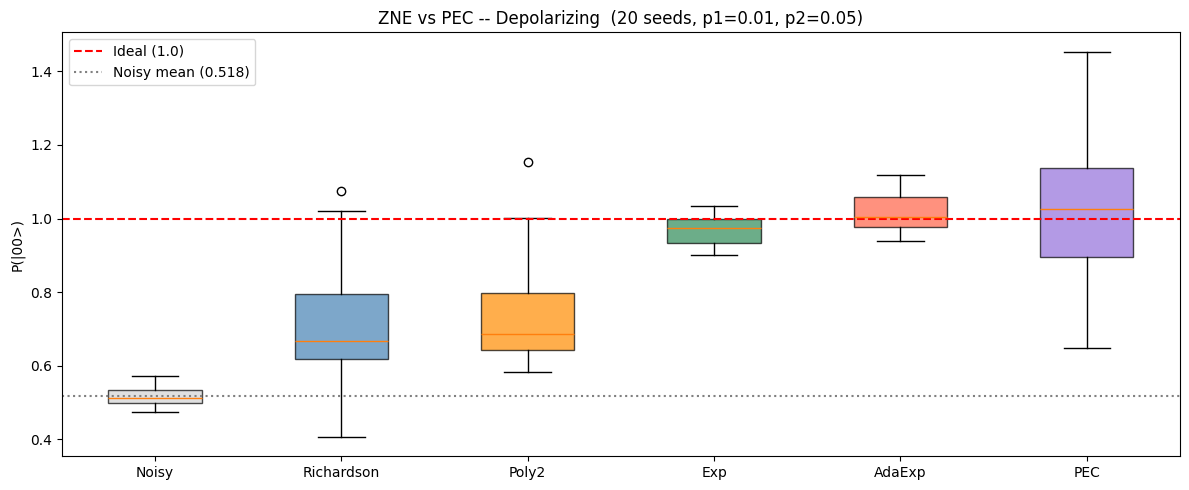

In [16]:
labels_all  = ['Noisy', 'Richardson', 'Poly2', 'Exp', 'AdaExp', 'PEC']
colors_all  = ['lightgray', 'steelblue', 'darkorange', 'seagreen', 'tomato', 'mediumpurple']
data_plot   = [np.asarray(raw_depol[k], dtype=float) for k in labels_all]
noisy_mean  = data_plot[0].mean()

fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(data_plot, labels=labels_all, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_all):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.axhline(IDEAL, color='red', ls='--', lw=1.5, label=f'Ideal ({IDEAL})')
ax.axhline(noisy_mean, color='gray', ls=':', lw=1.5, label=f'Noisy mean ({noisy_mean:.3f})')
ax.set_ylabel('P(|00>)')
ax.set_title(f'ZNE vs PEC -- Depolarizing  ({N_SEEDS} seeds, p1={P1}, p2={P2})')
ax.legend()
plt.tight_layout(); plt.show()

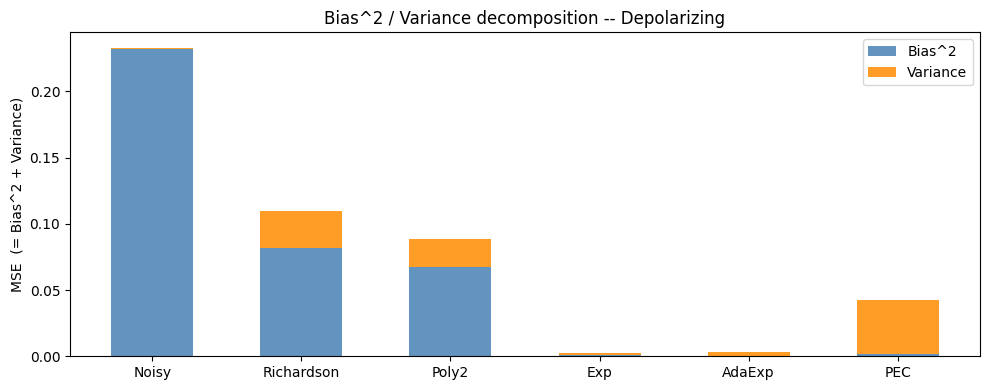

In [17]:
methods_plot = ['Noisy', 'Richardson', 'Poly2', 'Exp', 'AdaExp', 'PEC']
bias2_vals   = [df_depol.loc[('Depolarizing', m), 'bias']    **2 for m in methods_plot]
var_vals     = [df_depol.loc[('Depolarizing', m), 'variance']    for m in methods_plot]

x = np.arange(len(methods_plot)); width = 0.55
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x, bias2_vals, width, label='Bias^2',   color='steelblue',  alpha=0.85)
ax.bar(x, var_vals,   width, label='Variance', color='darkorange', alpha=0.85, bottom=bias2_vals)
ax.set_xticks(x); ax.set_xticklabels(methods_plot)
ax.set_ylabel('MSE  (= Bias^2 + Variance)')
ax.set_title('Bias^2 / Variance decomposition -- Depolarizing')
ax.legend()
plt.tight_layout(); plt.show()

In [18]:
# Equal-cost comparison: each method spends ~SHOT_BUDGET shots per circuit (run_benchmark).
print(f"Equal shot budget : {SHOT_BUDGET:,} shots / circuit / method  ({N_SEEDS} seeds)")
print(f"  non-adaptive ZNE : {SHOT_BUDGET // len(SCALE_FACTORS):>7,} shots x {len(SCALE_FACTORS)} lambda")
print(f"  AdaExp           : {SHOT_BUDGET // 4:>7,} shots x 4 steps")
print(f"  PEC              : {SHOT_BUDGET // SPEC_DEPOL.pec_shots:>7,} samples x {SPEC_DEPOL.pec_shots} shots")
print()
print("MSE comparison (Depolarizing):")
for m in ['Exp', 'AdaExp', 'PEC']:
    mse = df_depol.loc[('Depolarizing', m), 'mse']
    print(f"  {m:<10} MSE : {mse:.5f}")
print(f"  -> PEC overhead gamma_mean : {gammas_depol.mean():.3f}")

Equal shot budget : 30,000 shots / circuit / method  (20 seeds)
  non-adaptive ZNE :  10,000 shots x 3 lambda
  AdaExp           :   7,500 shots x 4 steps
  PEC              :     300 samples x 100 shots

MSE comparison (Depolarizing):
  Exp        MSE : 0.00281
  AdaExp     MSE : 0.00326
  PEC        MSE : 0.04263
  -> PEC overhead gamma_mean : 8.192


## 6. Extension to other noise models

Same benchmark, three additional `NoiseSpec`:
- **Amplitude damping** (T1-like) — relaxation to $|0\rangle$. Asymptote $\to 1$.
- **Phase damping** (T2-like) — pure dephasing, preserves diagonal populations.
- **Thermal relaxation** (T1+T2 composite) — `AD ∘ PD` applied sequentially.

For these non-depolarising channels, Mitiq has **no analytical helper for 2q gates** → we build the QPR
via `find_optimal_representation` (LP on a Pauli basis) using the §2.5 utilities.

Aer noise model = `kraus_error(K)` on 1q gates + `kraus_error(K).tensor(kraus_error(K))` on CX
(local channel on each qubit). The same Kraus operators are used to build the PEC representation
→ noise model perfectly matched.

In [19]:
# _build_with_cache lives in qem. Sanity check: 1q AD via LP-with-reset reproduces
# Takagi's universal gamma = (1+g)/(1-g).
_demo_kraus_ad = kraus_amplitude_damping_1q(0.01)
_qc_h = QuantumCircuit(1); _qc_h.h(0)
_rep_ad = represent_op_with_kraus_lp(_qc_h, _demo_kraus_ad, include_reset=True)
print(f"AD g=0.01 -> H rep gamma (LP)      = {_rep_ad.norm:.4f}")
print(f"             expected (Takagi)     = {1.01 / 0.99:.4f}")


AD g=0.01 -> H rep gamma (LP)      = 1.0202
             expected (Takagi)     = 1.0202


### 6.1 Amplitude damping (T1-like)

Per-qubit channel `D_γ(ρ) = K_0 ρ K_0^† + K_1 ρ K_1^†` with
`K_0 = diag(1, √(1−γ))`, `K_1 = [[0, √γ], [0, 0]]`.

`γ_1q = 0.01` per 1-qubit gate ; `γ_2q = 0.05` per qubit on each CX (independent).
The state relaxes towards `|0⟩` → asymptote of `P(|00⟩)` is **1.0**.

In [20]:
df_ad, raw_ad, gammas_ad = cached_benchmark(SPEC_AD, seeds=SEEDS, force=True)
print(f"Mean PEC overhead (gamma_circuit) : {gammas_ad.mean():.3f}")


[AmplitudeDamping]  seeds=20  asymptote=None  scale_factors=[1.0, 1.5, 2.0, 3.0, 5.0]
  shot_budget=30,000/circuit/method  ->  ZNE 6000x5, AdaExp 7500x4, PEC 300 samples x 100 shots
  seed 5/20 done
  seed 10/20 done
  seed 15/20 done
  seed 20/20 done
                               mean     bias  variance      mse  n_fail  gamma_pec_mean  infid_channel  infid_psucc
noise            method                                                                                            
AmplitudeDamping Noisy       0.5894 -0.41060   0.00400  0.17259       0             NaN   5.603514e-01     0.513250
                 Richardson  0.6751 -0.32489   0.54078  0.64633       0             NaN   5.968239e-01     0.406125
                 Poly2       0.7918 -0.20822   0.00503  0.04839       0             NaN   3.084609e-01     0.260250
                 Exp         0.9644 -0.03561   0.00572  0.00699       0             NaN   7.196552e-02     0.044500
                 AdaExp      0.9873 -0.01269   0.00

### 6.2 Phase damping (T2-like)

Per-qubit Kraus `K_0 = diag(1, √(1−λ))`, `K_1 = diag(0, √λ)`.  
Preserves populations, kills off-diagonal coherences.

`λ_1q = 0.01`, `λ_2q = 0.05` per qubit on each CX.  
For random Clifford `U` on `|00⟩`, the asymptote of `P(|00⟩) = Σ |c_i|⁴` averages around **0.25**
(uniform superposition → maximally mixed in the computational basis after dephasing).

In [21]:
df_pd, raw_pd, gammas_pd = cached_benchmark(SPEC_PD, seeds=SEEDS, force=True)
print(f"Mean PEC overhead (gamma_circuit) : {gammas_pd.mean():.3f}")


[PhaseDamping]  seeds=20  asymptote=0.25  scale_factors=[1.0, 1.5, 2.0]
  shot_budget=30,000/circuit/method  ->  ZNE 10000x3, AdaExp 7500x4, PEC 300 samples x 100 shots
  seed 5/20 done
  seed 10/20 done
  seed 15/20 done
  seed 20/20 done
                           mean     bias  variance      mse  n_fail  gamma_pec_mean  infid_channel  infid_psucc
noise        method                                                                                            
PhaseDamping Noisy       0.7289 -0.27111   0.00280  0.07631       0             NaN   3.408551e-01     0.338875
             Richardson  0.8192 -0.18081   0.03913  0.07182       0             NaN   2.072203e-01     0.226000
             Poly2       0.8069 -0.19314   0.04767  0.08497       0             NaN   2.072203e-01     0.241375
             Exp         0.9885 -0.01151   0.00022  0.00035       0             NaN   3.327152e-02     0.014375
             AdaExp      0.9603 -0.03973   0.00140  0.00298       0             NaN   9.

### 6.3 Thermal relaxation (T1+T2 composite)

Channel = `AD(γ_ad) ∘ PD(γ_pd)` applied sequentially on each qubit — 4 Kraus operators
(`K_ij = A_i · P_j`).

`γ_ad = γ_pd = 0.005` (1q), `0.025` (each CX qubit).

> ⚠️ **Approximation on 1q reps**: the LP on the {I, X, Y, Z, reset} basis is mathematically
> infeasible for `Rz(±π/2)` under composite non-unital noise (the basis cannot span the
> channel inverse for those complex rotations). We fall back to the Takagi AD helper with
> `γ_eff = γ_AD` for 1q gates — this captures the amplitude-damping part of the noise but
> ignores the (small) phase-damping contribution → expect a residual PEC bias.
> The 2q CX rep is built via LP on the full thermal Kraus, so it's exact.

In [22]:
df_th, raw_th, gammas_th = cached_benchmark(SPEC_TH, seeds=SEEDS, force=True)
print(f"Mean PEC overhead (gamma_circuit) : {gammas_th.mean():.3f}")


[ThermalRelaxation]  seeds=20  asymptote=None  scale_factors=[1.0, 1.5, 2.0, 3.0, 5.0]
  shot_budget=30,000/circuit/method  ->  ZNE 6000x5, AdaExp 7500x4, PEC 300 samples x 100 shots
  seed 5/20 done
  seed 10/20 done
  seed 15/20 done
  seed 20/20 done
                                mean     bias  variance      mse  n_fail  gamma_pec_mean  infid_channel  infid_psucc
noise             method                                                                                            
ThermalRelaxation Noisy       0.6508 -0.34920   0.00116  0.12311       0             NaN       0.465825     0.436500
                  Richardson  0.5386 -0.46143   0.35520  0.56812       0             NaN       0.593217     0.576750
                  Poly2       0.8682 -0.13183   0.00118  0.01856       0             NaN       0.190394     0.164750
                  Exp         0.9693 -0.03072   0.00168  0.00262       0             NaN       0.019548     0.038375
                  AdaExp      0.9802 -0.0198

### 6.4 Thermal relaxation (realistic -- T1/T2/gate durations)

Unlike the §6.3 model (hand-set γ_ad/γ_pd, identical for every 1-qubit gate), this model
uses Aer's `thermal_relaxation_error(T1, T2, gate_time)`: **each gate type relaxes in
proportion to its duration**.

- `rz` / `id`: virtual (duration 0) -> no noise added.
- `sx` / `sxdg` / `x` / `h`: short gates (~35 ns).
- `cx`: long gate (~400 ns) -> dominant relaxation, applied per qubit via `.tensor()`.

Parameters: T1 = 100 µs, T2 = 80 µs (T2 ≤ 2·T1 satisfied). This is the closest static
approximation to real T1/T2 relaxation. The model and its parameters live in
`qem/noise_models.py`.

**PEC representations (per-gate, derived from the durations).** Aer's zero-temperature,
T2 ≤ T1 relaxation channel is *exactly* the composite `AD(γ_ad) ∘ PD(γ_pd)` with

$$\gamma_{ad} = 1 - e^{-t/T_1}, \qquad \gamma_{pd} = 1 - e^{-2t/T_2 + t/T_1}$$

(AD fixes the population decay $e^{-t/T_1}$; PD supplies whatever coherence decay is left
once AD's $e^{-t/2T_1}$ is accounted for, so the total matches $e^{-t/T_2}$). This was
verified to machine precision against `thermal_relaxation_error` for every gate time
($\lVert S_{AD∘PD} - S_{\text{qiskit}}\rVert_\infty \sim 10^{-15}$), so PEC inverts the
exact channel — **no model mismatch, unbiased**.

Each gate gets its **own** $(\gamma_{ad}, \gamma_{pd})$ from its duration:
- **Physical 1q gates** (sx/sxdg/x/h): the full `AD+PD` thermal Kraus via LP — *exact*,
  not the AD-only Takagi approximation of §6.3. Feasible here because the only complex
  gate, `rz`, carries zero noise (so the Pauli+reset LP, which is infeasible for noised
  `Rz(±π/2)`, is never asked to invert one).
- **rz / id** (zero duration): an exact identity rep (Takagi at γ=0), robust to any angle.
- **CX** (both orientations): full thermal LP on the per-qubit Kraus → exact.

PEC overhead stays low (γ ≈ 1.25) — the noise is weak, so cancellation is cheap.

In [23]:
df_th_real, raw_th_real, gammas_th_real = cached_benchmark(SPEC_TH_REAL, seeds=SEEDS, force=True)
print(f"Mean PEC overhead (gamma_circuit) : {gammas_th_real.mean():.3f}")

[ThermalRealistic]  seeds=20  asymptote=None  scale_factors=[1.0, 1.5, 2.0, 3.0, 5.0]
  shot_budget=30,000/circuit/method  ->  ZNE 6000x5, AdaExp 7500x4, PEC 300 samples x 100 shots
  seed 5/20 done
  seed 10/20 done
  seed 15/20 done
  seed 20/20 done
  [warn] Exp: extrapolation failed on 2/20 seeds -> stats over the 18 that converged
  [warn] AdaExp: extrapolation failed on 5/20 seeds -> stats over the 15 that converged
                               mean     bias  variance      mse  n_fail  gamma_pec_mean  infid_channel  infid_psucc
noise            method                                                                                            
ThermalRealistic Noisy       0.9433 -0.05667   0.00011  0.00333       0             NaN       0.073982     0.070875
                 Richardson  0.7583 -0.24171   0.06827  0.12670       0             NaN       0.270872     0.302125
                 Poly2       1.0045  0.00446   0.00008  0.00010       0             NaN      -0.004860    -0.0

### 6.5 Mixed-unitary (biased Pauli channel)

A **mixed-unitary** channel `E(ρ) = Σ pᵢ Uᵢ ρ Uᵢ†`. Here a **biased Pauli channel** (combined
depolarizing + dephasing, Strikis et al. 2021):
`D(ε) = (1−ε)[I] + ε·(η/(η+1)·Z + 1/(3(η+1))·(X+Y+Z))` — `η` biases the channel toward dephasing
(Z), an X/Y/Z asymmetry that plain depolarizing lacks.

**Realistic parameterisation** (toward the composite hardware model, *not* the elevated pedagogical
scale of §6.1–6.3):
- `ε_1q = 1e-3`, `ε_2q = 5e-3` per qubit on each CX — the coherent/biased-Pauli residual left after
  calibration sits well below the incoherent budget (IBM CX total ≈ 7e-3). This keeps the noisy bias
  ≈ −0.09, in the ThermalRealistic range, rather than making this the dominant noise source.
- `η = 4` — dephasing-dominated bias, as on real devices (T2 < T1, ZZ terms).
- **Noise on physical gates only**: `rz`/`id` are virtual (zero-duration) → no error, matching
  ThermalRealistic. PEC builds an `ε=0` identity rep for them (untouched, no over-correction).

Aer model via `pauli_error`; the **PEC representation is analytic**
(`represent_operation_with_local_biased_noise`) → no LP needed, PEC included from the start with low
overhead (γ ≈ 1.3). The channel is unital → fixed point is *exactly* the maximally-mixed state for
every seed, so we keep `asymptote = 0.25` (a stable 2-param Exp fit, unlike the free-asymptote fit
that AD/thermal need); `scale_factors` extended to 5 points for this weak, near-linear signal.

In [24]:
df_mu, raw_mu, gammas_mu = cached_benchmark(SPEC_MIXED_UNITARY, seeds=SEEDS, force=True)
print(f"Mean PEC overhead (gamma_circuit) : {gammas_mu.mean():.3f}")

[MixedUnitary]  seeds=20  asymptote=0.25  scale_factors=[1.0, 1.5, 2.0, 3.0, 5.0]
  shot_budget=30,000/circuit/method  ->  ZNE 6000x5, AdaExp 7500x4, PEC 300 samples x 100 shots
  seed 5/20 done
  seed 10/20 done
  seed 15/20 done
  seed 20/20 done
                           mean     bias  variance      mse  n_fail  gamma_pec_mean  infid_channel  infid_psucc
noise        method                                                                                            
MixedUnitary Noisy       0.9032 -0.09680   0.00053  0.00990       0             NaN   1.219190e-01     0.121000
             Richardson  0.7347 -0.26528   0.16240  0.23277       0             NaN   3.347906e-01     0.331625
             Poly2       1.0002  0.00019   0.00008  0.00008       0             NaN  -1.350618e-03    -0.000250
             Exp         1.0039  0.00392   0.00015  0.00017       0             NaN  -6.238660e-04    -0.004875
             AdaExp      0.9971 -0.00289   0.00005  0.00006       0            

### 6.6 Cross-noise summary

Single DataFrame indexed by `(noise, method)`, columns `mean / bias / variance / mse / γ_PEC`.  
Heat-map and grouped boxplot follow.

Every noise model now has a PEC row (`ThermalRealistic` included, since §6.4 added its per-gate
thermal representations).

In [25]:
df_all_noises = pd.concat([df_depol, df_ad, df_pd, df_th, df_th_real, df_mu])
print(df_all_noises.to_string())

                                mean     bias  variance      mse  n_fail  gamma_pec_mean  infid_channel  infid_psucc
noise             method                                                                                            
Depolarizing      Noisy       0.5182 -0.48183   0.00074  0.23290       0             NaN   6.257382e-01     0.602250
                  Richardson  0.7145 -0.28546   0.02804  0.10952       0             NaN   3.471883e-01     0.356875
                  Poly2       0.7406 -0.25944   0.02088  0.08819       0             NaN   3.471883e-01     0.324250
                  Exp         0.9681 -0.03186   0.00180  0.00281       0             NaN   4.894852e-02     0.039875
                  AdaExp      1.0154  0.01539   0.00302  0.00326       0             NaN   4.642482e-03    -0.019250
                  PEC         1.0430  0.04303   0.04078  0.04263       0           8.192   6.424440e-04    -0.053750
AmplitudeDamping  Noisy       0.5894 -0.41060   0.00400  0.17259

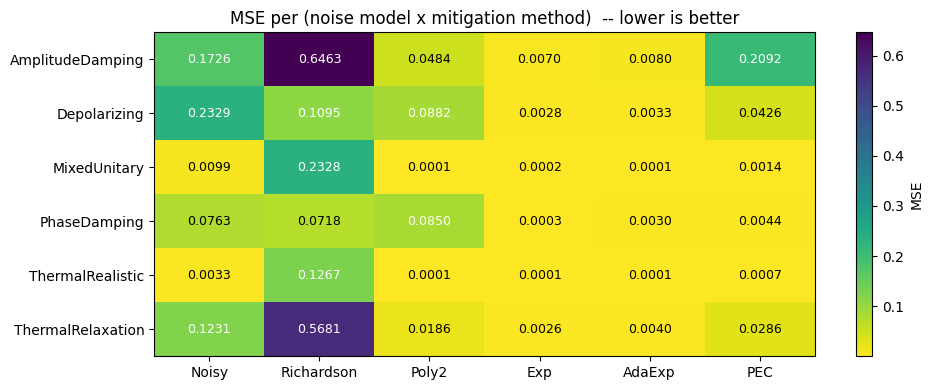

In [26]:
# MSE heat-map (noise x method) — lower is better
mse_pivot = df_all_noises['mse'].unstack(level='method')
mse_pivot = mse_pivot[['Noisy', 'Richardson', 'Poly2', 'Exp', 'AdaExp', 'PEC']]

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(mse_pivot.values, aspect='auto', cmap='viridis_r')
ax.set_xticks(range(len(mse_pivot.columns))); ax.set_xticklabels(mse_pivot.columns)
ax.set_yticks(range(len(mse_pivot.index)));   ax.set_yticklabels(mse_pivot.index)
for i in range(mse_pivot.shape[0]):
    for j in range(mse_pivot.shape[1]):
        _v = mse_pivot.values[i, j]
        ax.text(j, i, "—" if np.isnan(_v) else f"{_v:.4f}",
                ha='center', va='center',
                color='white' if (not np.isnan(_v) and _v > np.nanmean(mse_pivot.values)) else 'black',
                fontsize=9)
plt.colorbar(im, ax=ax, label='MSE')
ax.set_title('MSE per (noise model x mitigation method)  -- lower is better')
plt.tight_layout(); plt.show()

C:\Users\thoma\AppData\Local\Temp\ipykernel_13236\2342254154.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=present, patch_artist=True)
C:\Users\thoma\AppData\Local\Temp\ipykernel_13236\2342254154.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=present, patch_artist=True)
C:\Users\thoma\AppData\Local\Temp\ipykernel_13236\2342254154.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=present, patch_artist=True)
C:\Users\thoma\AppData\Local\Temp\ipykernel_13236\2342254154.py:14: MatplotlibDeprecationWarning: The 'labels' p

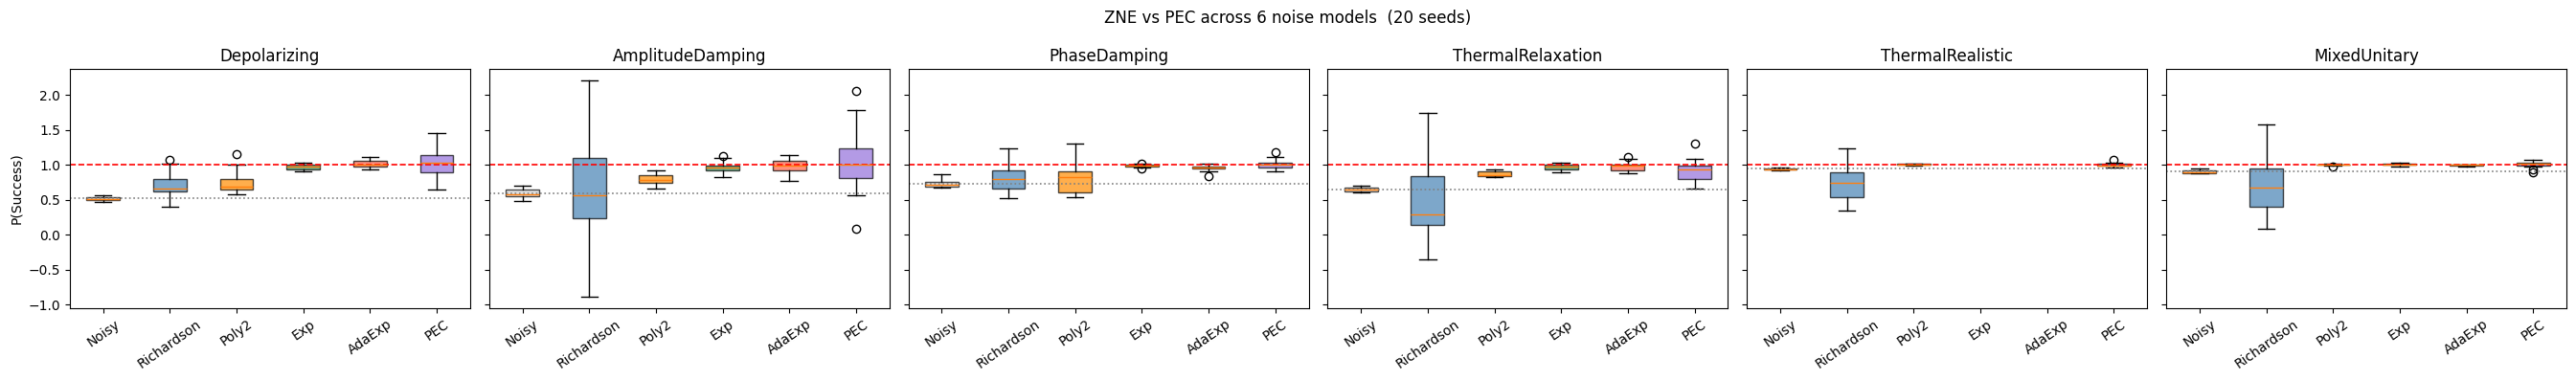

In [27]:
# Grouped boxplot: per-method distribution across all noise models
methods_g = ['Noisy', 'Richardson', 'Poly2', 'Exp', 'AdaExp', 'PEC']
noises_g  = [('Depolarizing', raw_depol), ('AmplitudeDamping', raw_ad),
             ('PhaseDamping', raw_pd),    ('ThermalRelaxation', raw_th),
             ('ThermalRealistic', raw_th_real), ('MixedUnitary', raw_mu)]
colors_g  = ['lightgray', 'steelblue', 'darkorange', 'seagreen', 'tomato', 'mediumpurple']

fig, axes = plt.subplots(1, len(noises_g), figsize=(4.5 * len(noises_g), 4), sharey=True)
for ax, (noise_name, raw) in zip(axes, noises_g):
    present = [k for k in methods_g if k in raw and len(raw[k])]
    data = [np.asarray(raw[k], dtype=float) for k in present]
    cols = [colors_g[methods_g.index(k)] for k in present]
    noisy_mean = np.asarray(raw['Noisy'], dtype=float).mean()
    bp = ax.boxplot(data, labels=present, patch_artist=True)
    for patch, c in zip(bp['boxes'], cols):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.axhline(IDEAL, color='red', ls='--', lw=1.2)
    ax.axhline(noisy_mean, color='gray', ls=':', lw=1.2)
    ax.set_title(noise_name)
    ax.tick_params(axis='x', rotation=35)
axes[0].set_ylabel('P(Success)')
plt.suptitle(f'ZNE vs PEC across {len(noises_g)} noise models  ({N_SEEDS} seeds)')
plt.tight_layout(); plt.show()